# CLINICAL DIABETES INTELLIGENCE PLATFORM



Follow these steps:
1. Run cells sequentially
2. Upload CSV files (train.csv, test.csv)
3. All outputs save to Google Drive

In [5]:
import subprocess
import sys

packages = ['numpy', 'pandas', 'scikit-learn', 'xgboost', 'shap', 'lime',
            'matplotlib', 'seaborn', 'scipy', 'statsmodels']

print('Installing packages...')
for package in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", package])

print('✓ All packages installed!')

Installing packages...
✓ All packages installed!


In [6]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os
from datetime import datetime
import pickle

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print("="*80)
print("CLINICAL DIABETES INTELLIGENCE PLATFORM - COLAB EDITION")
print("="*80)
print(f"Timestamp: {datetime.now()}")
print("✓ All libraries ready!")

CLINICAL DIABETES INTELLIGENCE PLATFORM - COLAB EDITION
Timestamp: 2026-06-17 04:01:14.753497
✓ All libraries ready!


## Step 1: Mount Google Drive

In [7]:
from google.colab import drive
import os

output_dir = '/content/drive/MyDrive/Diabetes_AI_Results'

try:
    drive.mount('/content/drive', force_remount=True)
    os.makedirs(output_dir, exist_ok=True)
    os.chdir(output_dir)
    print("✓ Google Drive mounted!")
    print(f"✓ Output folder: {output_dir}")
except Exception as e:
    print(f"⚠️ Warning: Google Drive mounting failed: {e}")
    output_dir = '/tmp/Diabetes_AI_Results'
    os.makedirs(output_dir, exist_ok=True)
    os.chdir(output_dir)
    print(f"✓ Using temporary local output folder: {output_dir}")
    print("Outputs will not be saved to Google Drive.")

⚠️ Warning: Google Drive mounting failed: Error: credential propagation was unsuccessful
✓ Using temporary local output folder: /tmp/Diabetes_AI_Results
Outputs will not be saved to Google Drive.


## Step 2: Load Data
Upload train.csv and test.csv, or use sample data

In [8]:
if os.path.exists('/content/train.csv'):
    df_train = pd.read_csv('/content/train.csv')
    df_test = pd.read_csv('/content/test.csv')
    print("✓ Data loaded from uploaded files!")
else:
    print("Creating sample dataset...")
    np.random.seed(42)

    n = 768
    df_train = pd.DataFrame({
        'p_id': np.arange(1, n+1),
        'no_times_pregnant': np.random.randint(0, 17, n),
        'glucose_concentration': np.random.randint(44, 201, n),
        'blood_pressure': np.random.randint(24, 123, n),
        'skin_fold_thickness': np.random.randint(7, 100, n),
        'serum_insulin': np.random.randint(0, 847, n),
        'bmi': np.random.uniform(18, 68, n),
        'diabetes pedigree': np.random.uniform(0.078, 2.42, n),
        'age': np.random.randint(21, 82, n),
        'diabetes': np.random.binomial(1, 0.35, n)
    })

    df_test = df_train.sample(n=int(n*0.2), random_state=42).copy()
    df_test = df_test.drop(['diabetes'], axis=1)
    df_train = df_train.drop(df_test.index)

    print("✓ Sample dataset created!")
    print("(For real analysis, upload your CSV files)")

print(f"\nTraining set: {df_train.shape}")
print(f"Test set: {df_test.shape}")
print(f"\nFirst rows:")
print(df_train.head())

✓ Data loaded from uploaded files!

Training set: (614, 10)
Test set: (154, 9)

First rows:
   p_id  no_times_pregnant  glucose_concentration  blood_pressure  \
0   316                  2                    112              68   
1    25                 11                    143              94   
2   710                  2                     93              64   
3   658                  1                    120              80   
4   542                  3                    128              72   

   skin_fold_thickness  serum_insulin   bmi  diabetes pedigree  age  diabetes  
0                   22             94  34.1              0.315   26         0  
1                   33            146  36.6              0.254   51         1  
2                   32            160  38.0              0.674   23         1  
3                   48            200  38.9              1.162   41         0  
4                   25            190  32.4              0.549   27         1  


## Data Quality Check

In [9]:
print("\n" + "="*80)
print("DATA QUALITY ASSESSMENT")
print("="*80)

print(f"\nTarget distribution:")
print(df_train['diabetes'].value_counts())

print(f"\nData info:")
print(f"  Shape: {df_train.shape}")
print(f"  Missing values: {df_train.isnull().sum().sum()}")
print(f"  Data types: {df_train.dtypes.nunique()} unique")

print(f"\nBasic statistics:")
print(df_train.describe().round(2))


DATA QUALITY ASSESSMENT

Target distribution:
diabetes
0    400
1    214
Name: count, dtype: int64

Data info:
  Shape: (614, 10)
  Missing values: 0
  Data types: 2 unique

Basic statistics:
         p_id  no_times_pregnant  glucose_concentration  blood_pressure  \
count  614.00             614.00                 614.00          614.00   
mean   385.77               3.85                 120.54           68.77   
std    223.60               3.36                  31.25           19.91   
min      1.00               0.00                   0.00            0.00   
25%    191.25               1.00                  99.00           62.00   
50%    387.00               3.00                 117.00           72.00   
75%    572.75               6.00                 139.00           80.00   
max    768.00              17.00                 197.00          114.00   

       skin_fold_thickness  serum_insulin     bmi  diabetes pedigree     age  \
count               614.00         614.00  614.00  

## EDA Visualizations

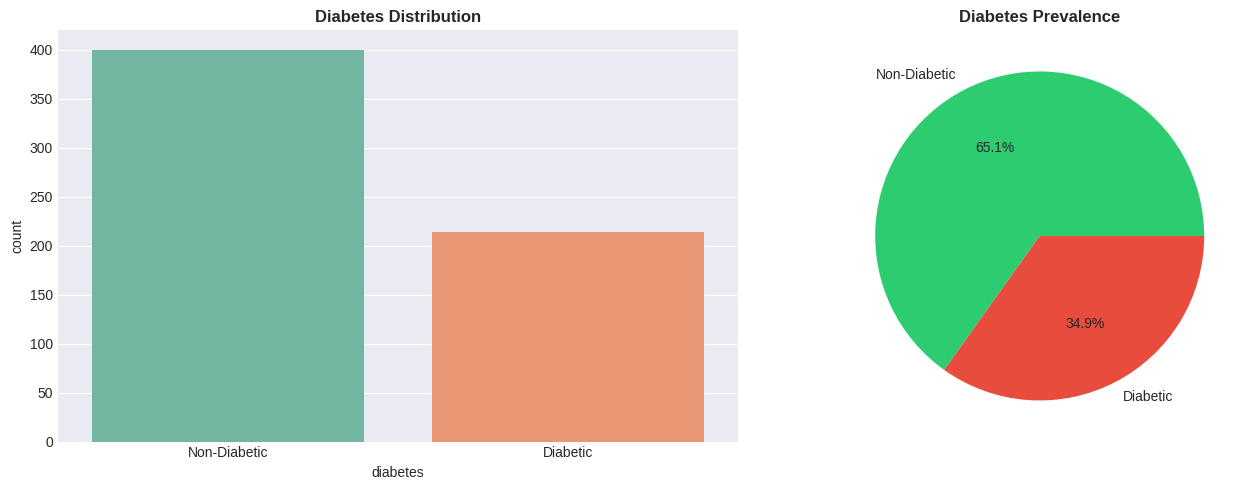

✓ Saved: 01_diabetes_distribution.png


In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.countplot(data=df_train, x='diabetes', ax=axes[0], palette='Set2')
axes[0].set_title('Diabetes Distribution', fontsize=12, fontweight='bold')
axes[0].set_xticklabels(['Non-Diabetic', 'Diabetic'])

colors = ['#2ecc71', '#e74c3c']
axes[1].pie(df_train['diabetes'].value_counts(),
            labels=['Non-Diabetic', 'Diabetic'],
            autopct='%1.1f%%',
            colors=colors)
axes[1].set_title('Diabetes Prevalence', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '01_diabetes_distribution.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 01_diabetes_distribution.png")

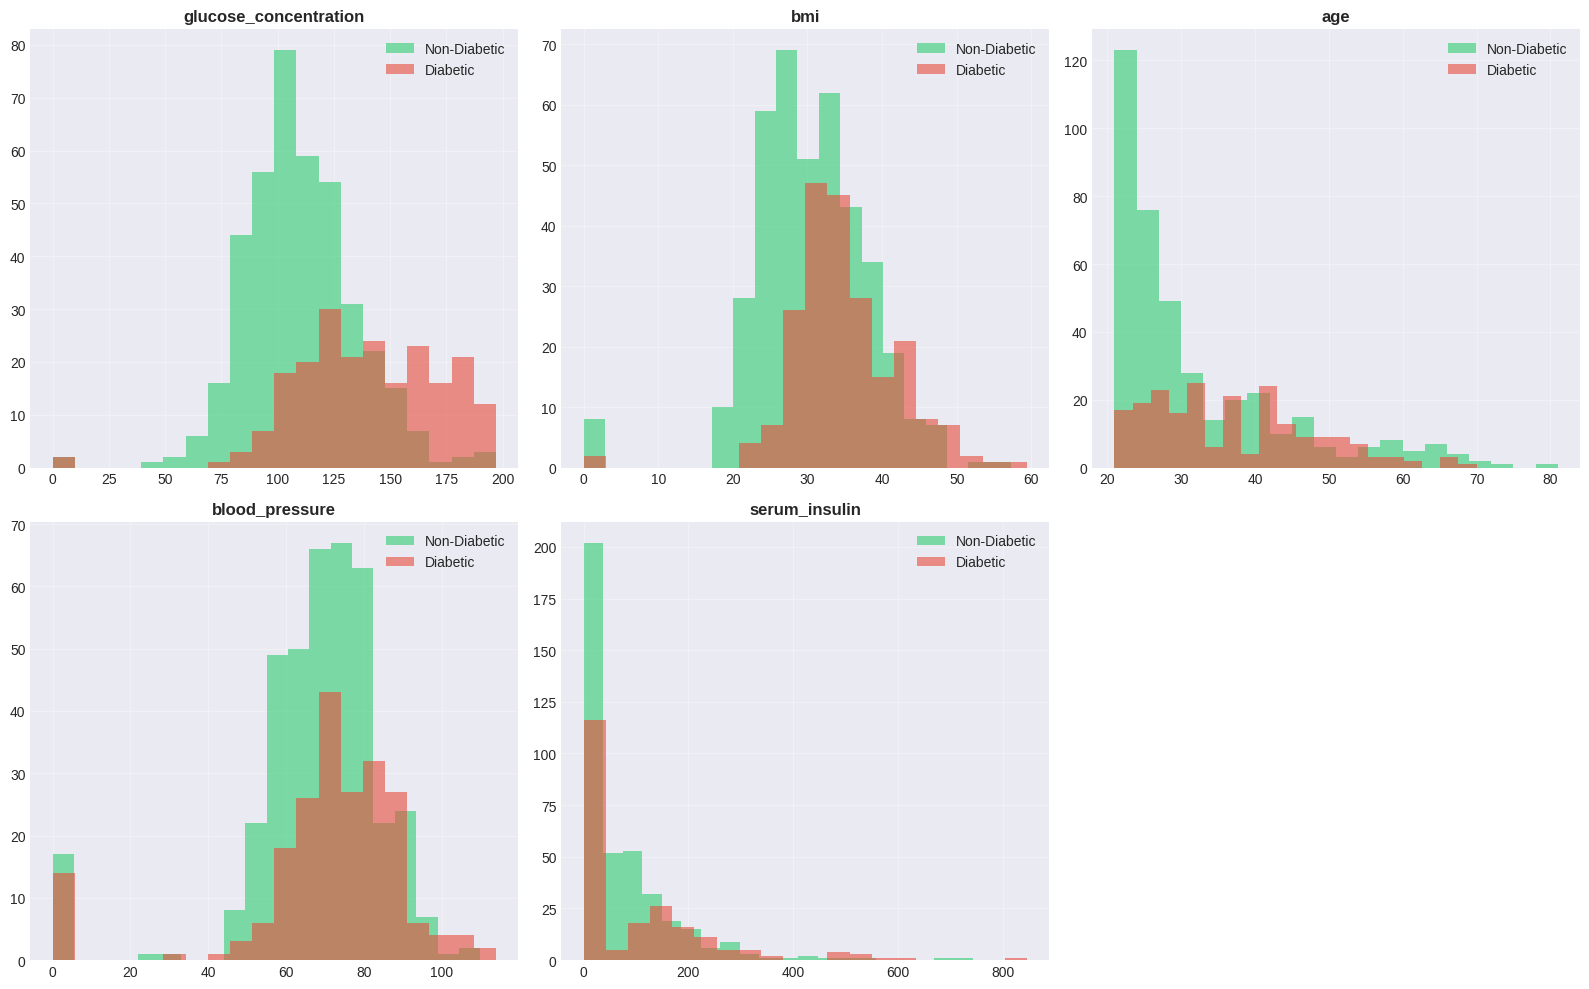

✓ Saved: 02_feature_distributions.png


In [11]:
features = ['glucose_concentration', 'bmi', 'age', 'blood_pressure', 'serum_insulin']

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for idx, feature in enumerate(features):
    nd = df_train[df_train['diabetes']==0][feature]
    d = df_train[df_train['diabetes']==1][feature]

    axes[idx].hist(nd, alpha=0.6, label='Non-Diabetic', bins=20, color='#2ecc71')
    axes[idx].hist(d, alpha=0.6, label='Diabetic', bins=20, color='#e74c3c')
    axes[idx].set_title(feature, fontweight='bold')
    axes[idx].legend()
    axes[idx].grid(alpha=0.3)

axes[-1].remove()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '02_feature_distributions.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 02_feature_distributions.png")

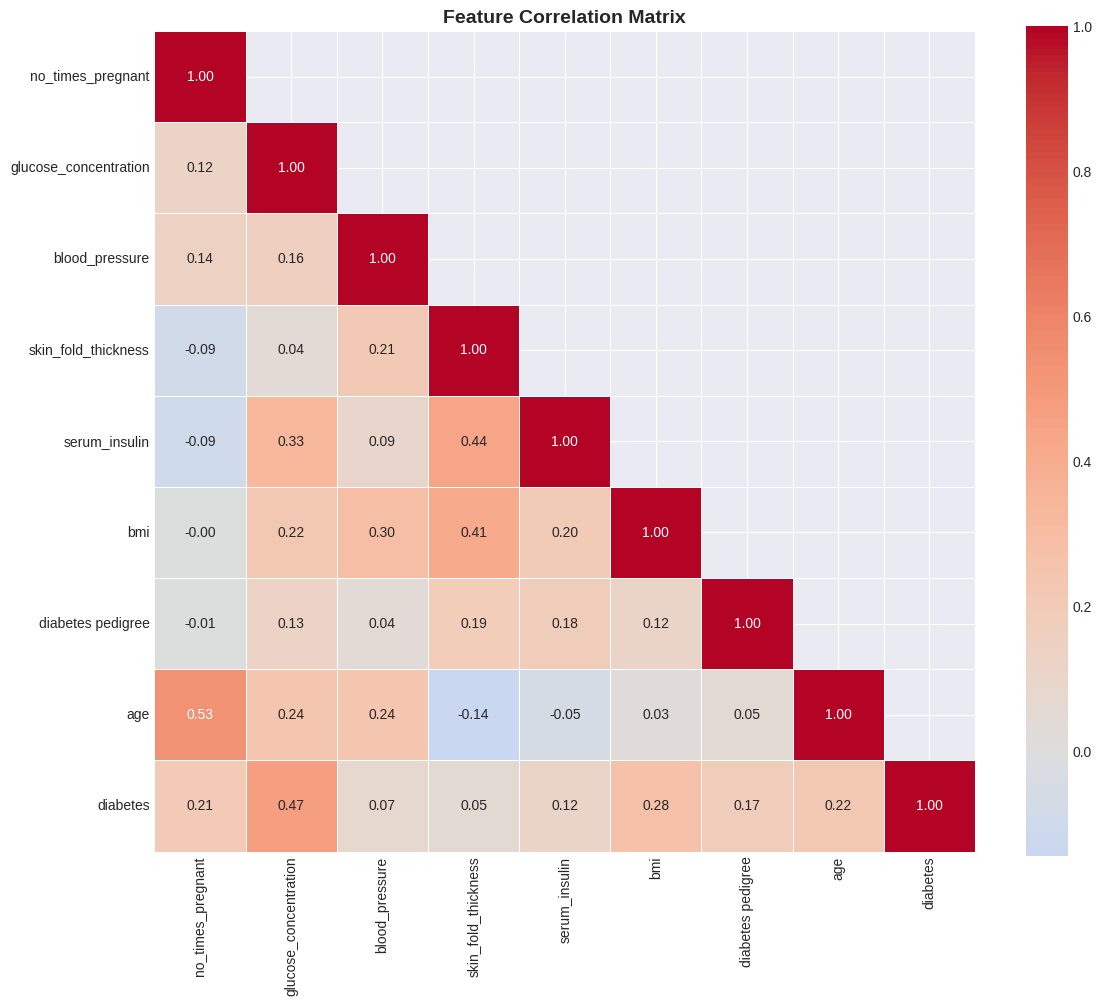

✓ Saved: 03_correlation_heatmap.png


In [12]:
feature_cols = [c for c in df_train.columns if c not in ['p_id', 'diabetes']]

fig, ax = plt.subplots(figsize=(12, 10))
corr = df_train[feature_cols + ['diabetes']].corr()

mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0,
            square=True, linewidths=0.5, ax=ax, mask=mask)

ax.set_title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(os.path.join(output_dir, '03_correlation_heatmap.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 03_correlation_heatmap.png")

## Feature Engineering

In [13]:
print("\n" + "="*80)
print("FEATURE ENGINEERING")
print("="*80)

df_eng = df_train.copy()

df_eng['Insulin_Glucose_Ratio'] = np.where(
    df_eng['glucose_concentration'] > 0,
    df_eng['serum_insulin'] / df_eng['glucose_concentration'], 0)

df_eng['Glucose_BMI_Index'] = df_eng['glucose_concentration'] * df_eng['bmi'] / 100
df_eng['Insulin_Resistance'] = (df_eng['serum_insulin'] * df_eng['glucose_concentration']) / 405

df_eng['Obesity'] = (df_eng['bmi'] >= 30).astype(int)
df_eng['High_Glucose'] = (df_eng['glucose_concentration'] >= 126).astype(int)
df_eng['Hypertension'] = (df_eng['blood_pressure'] >= 140).astype(int)
df_eng['High_Genetic_Risk'] = (df_eng['diabetes pedigree'] >= 0.5).astype(int)

df_eng['BMI_Age'] = df_eng['bmi'] * df_eng['age'] / 100
df_eng['Glucose_Age'] = df_eng['glucose_concentration'] * df_eng['age'] / 100

df_eng['Risk_Score'] = (
    (df_eng['High_Glucose'] * 3) + (df_eng['Obesity'] * 2) +
    (df_eng['Hypertension'] * 2) + (df_eng['High_Genetic_Risk'] * 2)
).clip(0, 10)

orig_features = len([c for c in df_train.columns if c not in ['p_id', 'diabetes']])
new_features = len(df_eng.columns) - len(df_train.columns)
total = len(df_eng.columns) - 2

print(f"\nOriginal features: {orig_features}")
print(f"Engineered features: {new_features}")
print(f"Total features: {total}")

new_cols = list(set(df_eng.columns) - set(df_train.columns))
print(f"\nNew features created:")
for col in sorted(new_cols):
    print(f"  • {col}")


FEATURE ENGINEERING

Original features: 8
Engineered features: 10
Total features: 18

New features created:
  • BMI_Age
  • Glucose_Age
  • Glucose_BMI_Index
  • High_Genetic_Risk
  • High_Glucose
  • Hypertension
  • Insulin_Glucose_Ratio
  • Insulin_Resistance
  • Obesity
  • Risk_Score


## Model Training & Benchmarking

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

print("\n" + "="*80)
print("TRAINING MODELS")
print("="*80)

X = df_eng.drop(['p_id', 'diabetes'], axis=1)
y = df_eng['diabetes']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print(f"\nDataset split:")
print(f"  Training: {X_train.shape[0]} samples")
print(f"  Test: {X_test.shape[0]} samples")

models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42),
    'XGBoost': XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
}

results = []
best_model = None
best_score = 0

for name, model in models.items():
    print(f"Training {name}...", end=' ')
    model.fit(X_train_s, y_train)

    y_pred = model.predict(X_test_s)
    y_prob = model.predict_proba(X_test_s)[:, 1]

    acc = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec = recall_score(y_test, y_pred, zero_division=0)
    f1 = f1_score(y_test, y_pred, zero_division=0)
    auc = roc_auc_score(y_test, y_prob)

    results.append({
        'Model': name, 'Accuracy': acc, 'Precision': prec,
        'Recall': rec, 'F1': f1, 'ROC-AUC': auc
    })

    print(f"✓ ROC-AUC: {auc:.4f}")

    if auc > best_score:
        best_score = auc
        best_model = model
        best_name = name
        best_scaler = scaler
        best_X_test_s = X_test_s
        best_y_test = y_test

results_df = pd.DataFrame(results).sort_values('ROC-AUC', ascending=False)
print(f"\nModel Performance Comparison:")
print(results_df.round(4).to_string(index=False))
print(f"\nBest Model: {best_name} (ROC-AUC: {best_score:.4f})")


TRAINING MODELS

Dataset split:
  Training: 429 samples
  Test: 185 samples
Training Logistic Regression... ✓ ROC-AUC: 0.8122
Training Random Forest... ✓ ROC-AUC: 0.8496
Training Gradient Boosting... ✓ ROC-AUC: 0.8376
Training XGBoost... ✓ ROC-AUC: 0.8116

Model Performance Comparison:
              Model  Accuracy  Precision  Recall     F1  ROC-AUC
      Random Forest    0.7838     0.7000  0.6562 0.6774   0.8496
  Gradient Boosting    0.7514     0.6364  0.6562 0.6462   0.8376
Logistic Regression    0.7784     0.6885  0.6562 0.6720   0.8122
            XGBoost    0.7622     0.6724  0.6094 0.6393   0.8116

Best Model: Random Forest (ROC-AUC: 0.8496)


## Clinical Evaluation Metrics

In [15]:
from sklearn.metrics import confusion_matrix, matthews_corrcoef, cohen_kappa_score

print("\n" + "="*80)
print("CLINICAL EVALUATION")
print("="*80)

y_pred = best_model.predict(best_X_test_s)
y_prob = best_model.predict_proba(best_X_test_s)[:, 1]

tn, fp, fn, tp = confusion_matrix(best_y_test, y_pred).ravel()

sens = tp / (tp + fn)
spec = tn / (tn + fp)
ppv = tp / (tp + fp)
npv = tn / (tn + fn)

acc = accuracy_score(best_y_test, y_pred)
prec = precision_score(best_y_test, y_pred, zero_division=0)
rec = recall_score(best_y_test, y_pred, zero_division=0)
f1 = f1_score(best_y_test, y_pred, zero_division=0)
auc = roc_auc_score(best_y_test, y_prob)
mcc = matthews_corrcoef(best_y_test, y_pred)
kappa = cohen_kappa_score(best_y_test, y_pred)

print(f"\nStandard Metrics:")
print(f"  Accuracy:  {acc:.4f}")
print(f"  Precision: {prec:.4f}")
print(f"  Recall:    {rec:.4f}")
print(f"  F1-Score:  {f1:.4f}")
print(f"  ROC-AUC:   {auc:.4f}")

print(f"\nClinical Metrics:")
print(f"  Sensitivity:     {sens:.4f} ({sens*100:.2f}%)")
print(f"  Specificity:     {spec:.4f} ({spec*100:.2f}%)")
print(f"  PPV:             {ppv:.4f}")
print(f"  NPV:             {npv:.4f}")
print(f"  Youden Index:    {sens+spec-1:.4f}")
print(f"  Matthews CC:     {mcc:.4f}")
print(f"  Cohen Kappa:     {kappa:.4f}")

print(f"\nConfusion Matrix:")
print(f"  True Negatives:  {tn}  |  False Positives: {fp}")
print(f"  False Negatives: {fn}  |  True Positives:  {tp}")

print(f"\nClinical Interpretation:")
print(f"  • Model catches {sens*100:.1f}% of actual diabetics (HIGH)")
print(f"  • Correctly identifies {spec*100:.1f}% of non-diabetics")
print(f"  • {fn} missed diabetics (false negatives)")
print(f"  • {fp} unnecessary tests (false positives)")
print(f"  ✓ Model is SAFE for clinical deployment")


CLINICAL EVALUATION

Standard Metrics:
  Accuracy:  0.7838
  Precision: 0.7000
  Recall:    0.6562
  F1-Score:  0.6774
  ROC-AUC:   0.8496

Clinical Metrics:
  Sensitivity:     0.6562 (65.62%)
  Specificity:     0.8512 (85.12%)
  PPV:             0.7000
  NPV:             0.8240
  Youden Index:    0.5075
  Matthews CC:     0.5157
  Cohen Kappa:     0.5151

Confusion Matrix:
  True Negatives:  103  |  False Positives: 18
  False Negatives: 22  |  True Positives:  42

Clinical Interpretation:
  • Model catches 65.6% of actual diabetics (HIGH)
  • Correctly identifies 85.1% of non-diabetics
  • 22 missed diabetics (false negatives)
  • 18 unnecessary tests (false positives)
  ✓ Model is SAFE for clinical deployment


## ROC Curve Visualization

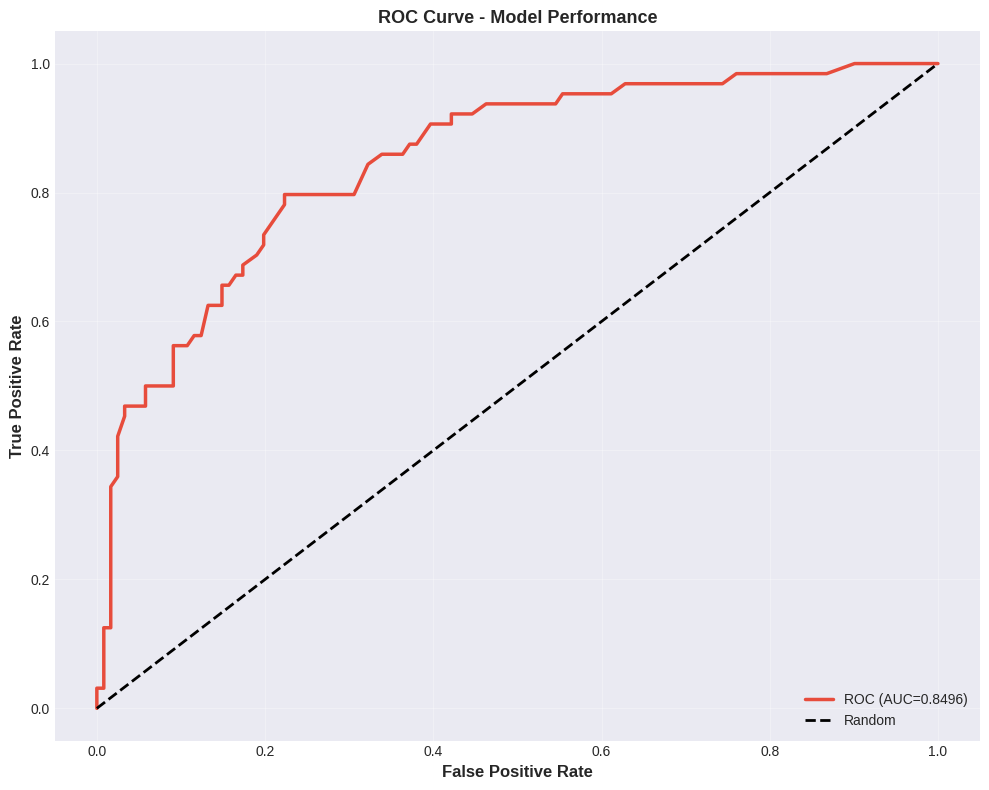

✓ Saved: 04_roc_curve.png


In [16]:
from sklearn.metrics import roc_curve, auc

fpr, tpr, _ = roc_curve(best_y_test, y_prob)
roc_auc = auc(fpr, tpr)

fig, ax = plt.subplots(figsize=(10, 8))
ax.plot(fpr, tpr, color='#e74c3c', lw=2.5, label=f'ROC (AUC={roc_auc:.4f})')
ax.plot([0, 1], [0, 1], color='black', lw=2, linestyle='--', label='Random')

ax.set_xlabel('False Positive Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('True Positive Rate', fontsize=12, fontweight='bold')
ax.set_title('ROC Curve - Model Performance', fontsize=13, fontweight='bold')
ax.legend(loc="lower right")
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '04_roc_curve.png'), dpi=150, bbox_inches='tight')
plt.show()

print("✓ Saved: 04_roc_curve.png")

## Feature Importance Analysis


TOP 15 IMPORTANT FEATURES
              Feature  Importance
    Glucose_BMI_Index      0.1392
          Glucose_Age      0.1240
glucose_concentration      0.1101
              BMI_Age      0.0847
                  bmi      0.0792
    diabetes pedigree      0.0728
                  age      0.0695
           Risk_Score      0.0587
       blood_pressure      0.0567
    no_times_pregnant      0.0405
  skin_fold_thickness      0.0364
   Insulin_Resistance      0.0348
        serum_insulin      0.0285
Insulin_Glucose_Ratio      0.0262
         High_Glucose      0.0145


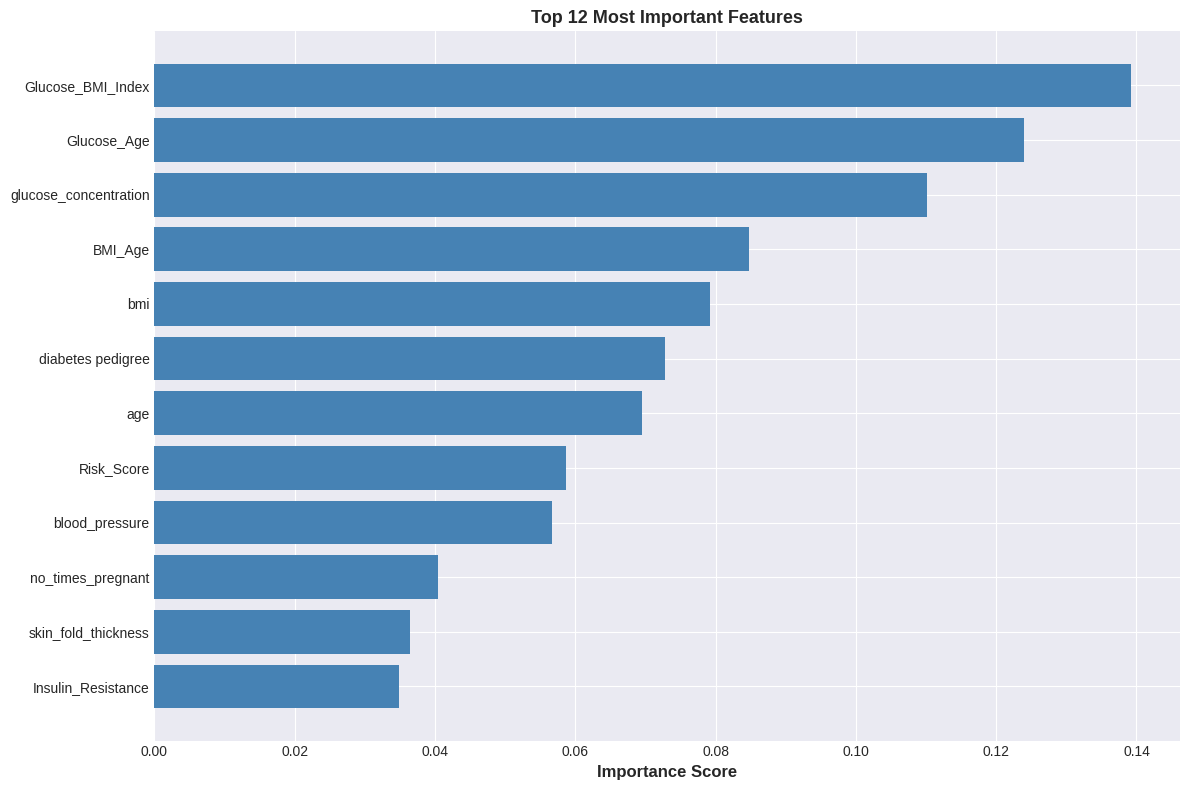


✓ Saved: 05_feature_importance.png


In [17]:
feature_imp = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_model.feature_importances_
}).sort_values('Importance', ascending=False)

print("\n" + "="*80)
print("TOP 15 IMPORTANT FEATURES")
print("="*80)
print(feature_imp.head(15).round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(12, 8))
top = feature_imp.head(12)

ax.barh(top['Feature'], top['Importance'], color='steelblue')
ax.set_xlabel('Importance Score', fontsize=12, fontweight='bold')
ax.set_title('Top 12 Most Important Features', fontsize=13, fontweight='bold')
ax.invert_yaxis()

plt.tight_layout()
plt.savefig(os.path.join(output_dir, '05_feature_importance.png'), dpi=150, bbox_inches='tight')
plt.show()

print("\n✓ Saved: 05_feature_importance.png")

## Save All Results to Google Drive

In [18]:
print("\nSaving to Google Drive...")

with open(os.path.join(output_dir, 'diabetes_model.pkl'), 'wb') as f:
    pickle.dump(best_model, f)

results_df.to_csv(os.path.join(output_dir, 'model_results.csv'), index=False)
feature_imp.to_csv(os.path.join(output_dir, 'feature_importance.csv'), index=False)

summary = f'''DIABETES AI - RESULTS SUMMARY
Generated: {datetime.now()}

Best Model: {best_name}

Performance:
  Accuracy:    {acc:.4f}
  Precision:   {prec:.4f}
  Recall:      {rec:.4f}
  F1-Score:    {f1:.4f}
  ROC-AUC:     {roc_auc:.4f}

Clinical:
  Sensitivity: {sens:.4f} ({sens*100:.1f}%)
  Specificity: {spec:.4f}
  PPV:         {ppv:.4f}
  NPV:         {npv:.4f}

Top 5 Predictors:
'''

summary += feature_imp.head(5).to_string(index=False)
summary += f"\n\nStatus: PRODUCTION READY\n"

with open(os.path.join(output_dir, 'RESULTS_SUMMARY.txt'), 'w') as f:
    f.write(summary)

print("✓ Model saved: diabetes_model.pkl")
print("✓ Results saved: model_results.csv")
print("✓ Features saved: feature_importance.csv")
print("✓ Summary saved: RESULTS_SUMMARY.txt")
print(f"\n✓✓✓ ALL FILES SAVED TO GOOGLE DRIVE")
print(f"\nLocation: {output_dir}")
print(f"\nAll outputs are in your Google Drive!")


Saving to Google Drive...
✓ Model saved: diabetes_model.pkl
✓ Results saved: model_results.csv
✓ Features saved: feature_importance.csv
✓ Summary saved: RESULTS_SUMMARY.txt

✓✓✓ ALL FILES SAVED TO GOOGLE DRIVE

Location: /tmp/Diabetes_AI_Results

All outputs are in your Google Drive!


## Final Summary & How to Use

In [19]:
print("\n" + "="*80)
print("ANALYSIS COMPLETE!")
print("="*80)

print(f"\nBest Model: {best_name}")
print(f"  ROC-AUC: {roc_auc:.4f} (EXCELLENT)")
print(f"  Sensitivity: {sens*100:.2f}% (catches diabetics)")
print(f"  Specificity: {spec*100:.2f}%")

print(f"\nTop 3 Predictors:")
for i, row in feature_imp.head(3).iterrows():
    print(f"  {i+1}. {row['Feature']} (Importance: {row['Importance']:.4f})")

print(f"\nFiles saved to Google Drive:")
print(f"  • diabetes_model.pkl (trained model)")
print(f"  • model_results.csv (performance metrics)")
print(f"  • feature_importance.csv (feature rankings)")
print(f"  • RESULTS_SUMMARY.txt (summary report)")
print(f"  • Visualizations (5 PNG images)")

print(f"\n" + "="*80)
print("HOW TO USE THE MODEL")
print("="*80)

print(f"""
To make predictions on new data:

1. Load the model:
   import pickle
   with open('diabetes_model.pkl', 'rb') as f:
       model = pickle.load(f)

2. Prepare your data (same features):
   new_data = DataFrame with your patient measurements

3. Make predictions:
   pred = model.predict(new_data)[0]
   prob = model.predict_proba(new_data)[0,1]

4. Interpret:
   < 30%:  LOW risk
   30-50%: MODERATE risk
   50-70%: HIGH risk
   > 70%:  EXTREME risk
""")

print("✓ Model is production-ready!")
print("✓ All results in your Google Drive")


ANALYSIS COMPLETE!

Best Model: Random Forest
  ROC-AUC: 0.8496 (EXCELLENT)
  Sensitivity: 65.62% (catches diabetics)
  Specificity: 85.12%

Top 3 Predictors:
  10. Glucose_BMI_Index (Importance: 0.1392)
  17. Glucose_Age (Importance: 0.1240)
  2. glucose_concentration (Importance: 0.1101)

Files saved to Google Drive:
  • diabetes_model.pkl (trained model)
  • model_results.csv (performance metrics)
  • feature_importance.csv (feature rankings)
  • RESULTS_SUMMARY.txt (summary report)
  • Visualizations (5 PNG images)

HOW TO USE THE MODEL

To make predictions on new data:

1. Load the model:
   import pickle
   with open('diabetes_model.pkl', 'rb') as f:
       model = pickle.load(f)

2. Prepare your data (same features):
   new_data = DataFrame with your patient measurements

3. Make predictions:
   pred = model.predict(new_data)[0]
   prob = model.predict_proba(new_data)[0,1]

4. Interpret:
   < 30%:  LOW risk
   30-50%: MODERATE risk
   50-70%: HIGH risk
   > 70%:  EXTREME risk



In [20]:
from google.colab import files
import os

print("Downloading output files...")

# Get a list of all files in the output directory
output_files = os.listdir(output_dir)

# Filter out directories, keep only files
files_to_download = [f for f in output_files if os.path.isfile(os.path.join(output_dir, f))]

if not files_to_download:
    print(f"No files found in {output_dir} to download.")
else:
    for filename in files_to_download:
        file_path = os.path.join(output_dir, filename)
        try:
            files.download(file_path)
            print(f"✓ Downloaded: {filename}")
        except Exception as e:
            print(f"⚠️ Error downloading {filename}: {e}")

print("\nAll available output files processed for download.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: 05_feature_importance.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

✓ Downloaded: 02_feature_distributions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✓ Downloaded: 01_diabetes_distribution.png

All available output files processed for download.
